# Notebook 9 — Análisis SHAP de las predicciones

**TFM**: Predicción y análisis de estrategias de carrera en Fórmula 1 mediante modelos de aprendizaje automático
**Autor**: Francisco Moreno Bayona

## Propósito

Este notebook complementa la comparativa cuantitativa de los notebooks 1-8 con un análisis de interpretabilidad basado en valores SHAP (*SHapley Additive exPlanations*) sobre los dos modelos ganadores:

- **XGBoost** para la tarea de clasificación (predicción de parada vuelta a vuelta).
- **LightGBM** para la tarea de regresión (vueltas hasta la siguiente parada).

El análisis se estructura en dos niveles:

1. **Interpretabilidad global**: identifica las variables que más contribuyen a las predicciones agregadas y, mediante *dependence plots*, caracteriza el patrón de contribución de las variables más influyentes en función de su valor.
2. **Interpretabilidad local**: examina cuatro casos concretos de error del clasificador, uno por cada tipología descrita en la sección 6.6 de la memoria (paradas reactivas, undercut táctico, estrategias atípicas y errores en extremos de carrera). Para cada caso se genera un *waterfall plot* que descompone la predicción del modelo en contribuciones individuales por variable.

Los resultados se exportan como figuras de alta resolución listas para incorporar en la memoria y como un CSV resumen con los casos analizados.

## Estructura del notebook

1. Configuración de rutas y parámetros
2. Imports y configuración gráfica
3. Carga de datos, *splits* y modelos entrenados
4. SHAP global: modelo de clasificación
5. SHAP global: modelo de regresión
6. Identificación y categorización de los casos de error
7. SHAP local: un caso por tipología
8. Resumen consolidado y exportación


## 1. Configuración

Las rutas se centralizan en este bloque para facilitar la reproducción. Ajusta los nombres si tus archivos están guardados con convenciones distintas.

**Entrada esperada**:
- Dataset con las 25 variables avanzadas y los identificadores de carrera/piloto/vuelta.
- *Splits* temporales coherentes con los empleados en los notebooks 5-7.
- Modelos entrenados y persistidos (`joblib` o `pickle`).

**Salida**:
- Figuras `.png` en alta resolución (300 dpi) en el directorio `outputs/`.
- CSV con la tabla resumen de casos analizados.


In [1]:
import sys
print(sys.version)

3.11.3 (tags/v3.11.3:f3909b8, Apr  4 2023, 23:49:59) [MSC v.1934 64 bit (AMD64)]


In [2]:
import sklearn, xgboost, lightgbm, shap, pandas, numpy, fastf1, matplotlib, seaborn
for m in [sklearn, xgboost, lightgbm, shap, pandas, numpy, fastf1, matplotlib, seaborn]:
    print(m.__name__, m.__version__)

C:\Users\franm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sklearn 1.9.0
xgboost 3.2.0
lightgbm 4.6.0
shap 0.51.0
pandas 3.0.3
numpy 2.4.6
fastf1 3.8.3
matplotlib 3.8.4
seaborn 0.12.2


In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Rutas adaptadas a la estructura del proyecto TFM_F1
# Asume que el notebook se ejecuta desde la raíz del proyecto (TFM_F1/)
DATA_DIR = "datasets/prepared"
MODELS_DIR = "datasets/prepared"
OUTPUTS_DIR = "datasets/prepared/shap_outputs"

# Splits train/test con las 25 features avanzadas (generados al final del NB5)
PATH_TRAIN_CLF = f"{DATA_DIR}/train_clasificacion_avanzado.csv"
PATH_TEST_CLF  = f"{DATA_DIR}/test_clasificacion_avanzado.csv"
PATH_TRAIN_REG = f"{DATA_DIR}/train_regresion_avanzado.csv"
PATH_TEST_REG  = f"{DATA_DIR}/test_regresion_avanzado.csv"

# Modelos v2 (entrenados con las 25 variables avanzadas)
PATH_XGB_CLF  = f"{MODELS_DIR}/modelo_v2_clasif_xgboost.pkl"
PATH_LGBM_REG = f"{MODELS_DIR}/modelo_v2_regres_lightgbm.pkl"

# Nombres de columnas objetivo (verificados sobre los CSVs reales)
COL_TARGET_CLF = "target_parada"         # columna objetivo binaria en train/test_clasificacion.csv
COL_TARGET_REG = "LapsUntilNextStop"     # columna objetivo en train/test_regresion_v2.csv

# Parámetros del análisis
N_SHAP_SAMPLES = 3000        # nº de muestras para SHAP (memoria vs precisión)
RANDOM_STATE = 42
DPI_FIGURAS = 300            # resolución de exportación
TOP_VARIABLES_PLOT = 15      # variables a mostrar en summary plots
TOP_DEPENDENCE = 3           # número de dependence plots a generar por tarea


## 2. Imports y configuración gráfica

In [2]:
import os
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import shap
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Configuración matplotlib coherente con el resto del trabajo
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": DPI_FIGURAS,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Crear directorio de salida si no existe
Path(OUTPUTS_DIR).mkdir(parents=True, exist_ok=True)

print(f"shap:    {shap.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"numpy:   {np.__version__}")
print(f"pandas:  {pd.__version__}")
print(f"Directorio de salida: {Path(OUTPUTS_DIR).resolve()}")

# Aviso de compatibilidad: XGBoost >= 3.0 con SHAP < 0.47 produce error en TreeExplainer
# por el cambio de formato de base_score (escalar → lista).
def _ver_tuple(v):
    return tuple(int(x) for x in v.split(".")[:2] if x.isdigit())

if _ver_tuple(xgb.__version__) >= (3, 0) and _ver_tuple(shap.__version__) < (0, 47):
    print("\n⚠️  ATENCIÓN: detectada combinación XGBoost ≥ 3.0 con SHAP < 0.47.")
    print("    Es probable que TreeExplainer falle. Se recomienda:")
    print("      pip install --upgrade shap")
    print("    Si no es posible, el notebook aplicará un workaround automáticamente.")


C:\Users\franm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap:    0.51.0
xgboost: 3.2.0
numpy:   2.4.6
pandas:  3.0.3
Directorio de salida: C:\Users\franm\TFM_F1\datasets\prepared\shap_outputs


## 3. Carga de datos, *splits* y modelos entrenados

Esta sección carga directamente los CSVs de train/test ya generados en notebooks anteriores y los modelos `v2` persistidos en `datasets/prepared/`.

**Estrategia**:
- La clasificación usa `train_clasificacion.csv` / `test_clasificacion.csv` (que ya contienen las 25 variables avanzadas).
- La regresión usa `train_regresion_v2.csv` / `test_regresion_v2.csv` (versión con el target corregido `laps_until_next_stop`, sin la fuga de información del `LapNumber` original).

**Nota sobre los modelos**: utilizamos los `modelo_v2_*` (entrenados con las 25 variables avanzadas en el notebook 5). Si en su momento se hubieran persistido modelos posteriores tras la corrección de gaps físicos del notebook 7, deberían sustituirse aquí; en su defecto, los `v2` son la opción consistente más reciente.

### 3.1 Inspección rápida de los CSVs

Antes de definir `X` e `y` conviene verificar los nombres reales de las columnas para detectar si las constantes `COL_TARGET_CLF` y `COL_TARGET_REG` definidas en la sección 1 coinciden con los nombres en el CSV. Si difieren, basta con ajustar esas dos constantes.

In [3]:
# Cargar los CSVs
df_train_clf = pd.read_csv(PATH_TRAIN_CLF)
df_test_clf  = pd.read_csv(PATH_TEST_CLF)
df_train_reg = pd.read_csv(PATH_TRAIN_REG)
df_test_reg  = pd.read_csv(PATH_TEST_REG)

print(f"train_clasificacion: {df_train_clf.shape}")
print(f"test_clasificacion:  {df_test_clf.shape}")
print(f"train_regresion_v2:  {df_train_reg.shape}")
print(f"test_regresion_v2:   {df_test_reg.shape}")

print("\n=== Columnas de test_clasificacion.csv ===")
print(df_test_clf.columns.tolist())
print("\n=== Columnas de test_regresion_v2.csv ===")
print(df_test_reg.columns.tolist())


train_clasificacion: (74392, 33)
test_clasificacion:  (18599, 33)
train_regresion_v2:  (42691, 33)
test_regresion_v2:   (10673, 33)

=== Columnas de test_clasificacion.csv ===
['Season', 'Round', 'EventName', 'EventDate', 'Driver', 'StopLapNumber', 'LapsUntilNextStop', 'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator', 'GapAhead', 'GapBehind', 'IsInDRSWindow', 'NumStopsDone', 'LapsInCurrentStint', 'RemainingLaps', 'RemainingLapsPct', 'DegradationTrend', 'DegradationAccel', 'DeltaVsBestLap', 'AvgTime_CurrentStint', 'DeltaVsFieldMean', 'ZScoreVsField', 'PositionNormalized', 'target_parada']

=== Columnas de test_regresion_v2.csv ===
['Season', 'Round', 'EventName', 'EventDate', 'Driver', 'StopLapNumber', 'LapsUntilNextStop', 'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator', 'G

### 3.2 Construcción de X e y

Identificamos las columnas que NO son features (target + identificadores) y construimos `X_train`, `X_test`, `y_train_clf`, `y_test_clf`, `y_train_reg`, `y_test_reg`.

**Si tras la inspección anterior el nombre del target es diferente**, ajusta `COL_TARGET_CLF` y `COL_TARGET_REG` en la sección 1 y vuelve a ejecutar.

**Sobre las columnas de metadatos**: variables como `Year`, `RaceRound`, `Driver`, `LapNumber`, etc., son identificadores que no entran al modelo pero sí los necesitamos en la sección 6 para categorizar los errores. Las separamos en `meta_*` y las features en `X_*`.

In [4]:
# Listado de columnas a excluir de X (target + identificadores comunes)
# IMPORTANTE: StopLapNumber se excluye porque contiene el número de vuelta de la parada (info del futuro)
COLS_META_POSIBLES = [
    COL_TARGET_CLF, COL_TARGET_REG,
    "Year", "year", "Season",
    "RaceRound", "round", "Round",
    "Driver", "driver", "DriverNumber",
    "Team", "team",
    "lap_number", "Lap",
    "Circuit", "circuit", "EventName",
    "Date", "date", "EventDate",
    "StopLapNumber",  # crítico: contiene info de la parada (no debe entrar al modelo ni al SHAP)
]

def separar_X_y(df, col_target):
    """Separa el DataFrame en X (features), y (target) y meta (identificadores)."""
    cols_meta_presentes = [c for c in COLS_META_POSIBLES if c in df.columns]
    X = df.drop(columns=cols_meta_presentes)
    y = df[col_target]
    meta = df[[c for c in cols_meta_presentes if c != col_target]].copy()
    return X, y, meta

X_train_clf, y_train_clf, meta_train_clf = separar_X_y(df_train_clf, COL_TARGET_CLF)
X_test_clf,  y_test_clf,  meta_test_clf  = separar_X_y(df_test_clf,  COL_TARGET_CLF)
X_train_reg, y_train_reg, meta_train_reg = separar_X_y(df_train_reg, COL_TARGET_REG)
X_test_reg,  y_test_reg,  meta_test_reg  = separar_X_y(df_test_reg,  COL_TARGET_REG)

print(f"X_test_clf: {X_test_clf.shape} — features: {list(X_test_clf.columns)[:5]}...")
print(f"y_test_clf — proporción de paradas: {y_test_clf.mean():.4f}")
print(f"X_test_reg: {X_test_reg.shape}")
print(f"y_test_reg — rango: [{y_test_reg.min()}, {y_test_reg.max()}], media: {y_test_reg.mean():.2f}")
print(f"\nmeta_test_clf columnas: {list(meta_test_clf.columns)}")

# Para el resto del notebook, asumimos que las features son las mismas en clasificación y regresión
# (ambas usan las 25 variables avanzadas). Lo verificamos:
features_iguales = list(X_test_clf.columns) == list(X_test_reg.columns)
print(f"\n¿Mismas features en clf y reg? {features_iguales}")
if not features_iguales:
    diff_clf = set(X_test_clf.columns) - set(X_test_reg.columns)
    diff_reg = set(X_test_reg.columns) - set(X_test_clf.columns)
    print(f"  Solo en clf: {diff_clf}")
    print(f"  Solo en reg: {diff_reg}")


X_test_clf: (18599, 25) — features: ['LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber']...
y_test_clf — proporción de paradas: 0.0291
X_test_reg: (10673, 25)
y_test_reg — rango: [0, 71], media: 13.61

meta_test_clf columnas: ['LapsUntilNextStop', 'Season', 'Round', 'Driver', 'EventName', 'EventDate', 'StopLapNumber']

¿Mismas features en clf y reg? True


### 3.3 Carga de los modelos

In [5]:
def cargar_pickle(ruta):
    """Carga un archivo persistido con pickle/joblib."""
    with open(ruta, "rb") as f:
        return pickle.load(f)

modelo_clf = cargar_pickle(PATH_XGB_CLF)
modelo_reg = cargar_pickle(PATH_LGBM_REG)
print(f"Modelo de clasificación: {type(modelo_clf).__name__}")
print(f"Modelo de regresión: {type(modelo_reg).__name__}")

# Verificación rápida: el modelo debe esperar el mismo número de features que tenemos en X_test
# (XGBoost expone n_features_in_, LightGBM expone n_features_)
n_feat_clf = getattr(modelo_clf, "n_features_in_", None) or getattr(modelo_clf, "n_features_", None)
n_feat_reg = getattr(modelo_reg, "n_features_in_", None) or getattr(modelo_reg, "n_features_", None)
print(f"\nFeatures esperadas por modelo_clf: {n_feat_clf} | en X_test_clf: {X_test_clf.shape[1]}")
print(f"Features esperadas por modelo_reg: {n_feat_reg} | en X_test_reg: {X_test_reg.shape[1]}")


Modelo de clasificación: XGBClassifier
Modelo de regresión: LGBMRegressor

Features esperadas por modelo_clf: 25 | en X_test_clf: 25
Features esperadas por modelo_reg: 25 | en X_test_reg: 25


### 3.4 Muestreo para SHAP

El cálculo de SHAP sobre el conjunto completo de prueba puede ser costoso. Se utilizan muestras estratificadas independientes para clasificación y regresión (los splits no contienen exactamente las mismas vueltas: regresión filtra las vueltas que no tienen parada posterior).

Si tu equipo lo permite, sube `N_SHAP_SAMPLES` para obtener una estimación más estable; si es lento, redúcelo.

In [6]:
from sklearn.model_selection import train_test_split

# --- Muestra estratificada para clasificación ---
if len(X_test_clf) > N_SHAP_SAMPLES:
    X_shap_clf, _, y_shap_clf, _ = train_test_split(
        X_test_clf, y_test_clf,
        train_size=N_SHAP_SAMPLES,
        stratify=y_test_clf,
        random_state=RANDOM_STATE,
    )
else:
    X_shap_clf = X_test_clf.copy()
    y_shap_clf = y_test_clf.copy()

# --- Muestra (aleatoria, no estratificada) para regresión ---
if len(X_test_reg) > N_SHAP_SAMPLES:
    X_shap_reg, _, y_shap_reg, _ = train_test_split(
        X_test_reg, y_test_reg,
        train_size=N_SHAP_SAMPLES,
        random_state=RANDOM_STATE,
    )
else:
    X_shap_reg = X_test_reg.copy()
    y_shap_reg = y_test_reg.copy()

print(f"Muestra SHAP clasificación: {X_shap_clf.shape[0]:,} filas — paradas: {y_shap_clf.sum():,} ({y_shap_clf.mean()*100:.2f}%)")
print(f"Muestra SHAP regresión:     {X_shap_reg.shape[0]:,} filas")


Muestra SHAP clasificación: 3,000 filas — paradas: 87 (2.90%)
Muestra SHAP regresión:     3,000 filas


## 4. Análisis SHAP global — modelo de clasificación (XGBoost)

Se utiliza `shap.TreeExplainer`, que está optimizado para modelos basados en árboles y proporciona los valores SHAP exactos (no aproximados). Para la clasificación binaria, los valores SHAP están expresados en la escala del *log-odds*: contribuciones positivas elevan la probabilidad de parada, contribuciones negativas la reducen.

### 4.1 Cálculo de valores SHAP

In [7]:
# API moderna de SHAP: agnóstica al tipo de modelo y robusta a cambios de versión
# entre SHAP y XGBoost. Auto-detecta TreeExplainer cuando es posible.

# Reordenar X_shap_clf para que coincida con el orden de features del modelo
if hasattr(modelo_clf, 'feature_names_in_'):
    X_shap_clf = X_shap_clf[list(modelo_clf.feature_names_in_)]

explainer_clf = shap.Explainer(modelo_clf)
shap_explanation_clf = explainer_clf(X_shap_clf)

# shap_explanation_clf es un objeto Explanation que normaliza el formato
shap_values_clf = shap_explanation_clf.values
base_value_clf = shap_explanation_clf.base_values

# Para clasificación binaria, según versión de SHAP, shape puede ser:
#   - (n_samples, n_features)        — un único array para la clase positiva
#   - (n_samples, n_features, 2)     — un array por clase
# Normalizamos al primer caso
if shap_values_clf.ndim == 3:
    shap_values_clf = shap_values_clf[:, :, 1]   # clase positiva = parada
    if hasattr(base_value_clf, '__len__') and not np.isscalar(base_value_clf):
        base_value_clf = np.asarray(base_value_clf)
        if base_value_clf.ndim == 2:
            base_value_clf = float(base_value_clf[0, 1])
        else:
            base_value_clf = float(base_value_clf[1])

# Si base_value_clf es un array, tomamos el escalar correspondiente
if hasattr(base_value_clf, '__len__') and not np.isscalar(base_value_clf):
    base_value_clf = float(np.asarray(base_value_clf).flatten()[0])

print(f"shap_values_clf shape: {shap_values_clf.shape}")
print(f"base value (log-odds): {base_value_clf:.4f}")
print(f"  probabilidad base: {1/(1+np.exp(-base_value_clf)):.4f}")

shap_values_clf shape: (3000, 25)
base value (log-odds): 0.3166
  probabilidad base: 0.5785


### 4.2 Importancia global de variables (barras)

Promedio del valor absoluto de SHAP a lo largo de la muestra. Es comparable conceptualmente con `feature_importances_` pero más fiable: tiene en cuenta interacciones y desbalance.

> **Interpretación esperada**: las variables de ritmo relativo respecto a coches adyacentes deberían dominar, seguidas por indicadores de degradación y por las variables del historial de carrera (sección 6.4 de la memoria).

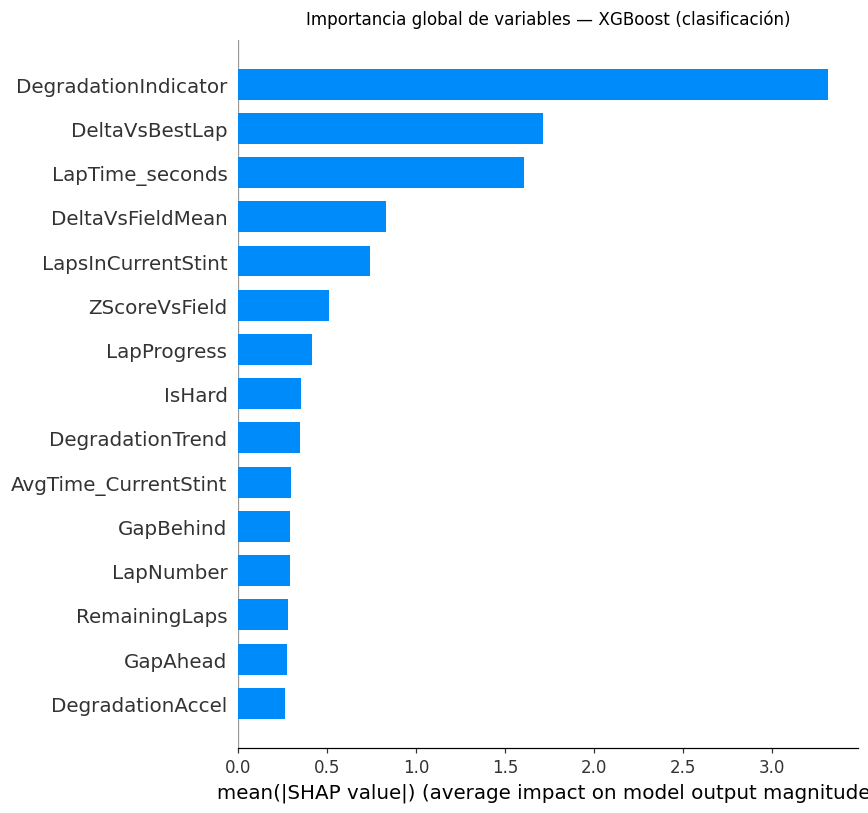

In [8]:
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_clf, X_shap_clf,
    plot_type="bar",
    max_display=TOP_VARIABLES_PLOT,
    show=False,
)
plt.title("Importancia global de variables — XGBoost (clasificación)", pad=10)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/fig_shap_global_clf_barras.png", dpi=DPI_FIGURAS, bbox_inches="tight")
plt.show()


### 4.3 Importancia global con direccionalidad (*beeswarm*)

Cada punto es una observación. La posición horizontal indica la magnitud y el signo de la contribución SHAP, y el color indica si el valor de la variable era alto o bajo. Esta visualización permite responder no solo *qué variables* importan, sino *cómo* lo hacen: si valores altos de una variable elevan o reducen la probabilidad de parada.

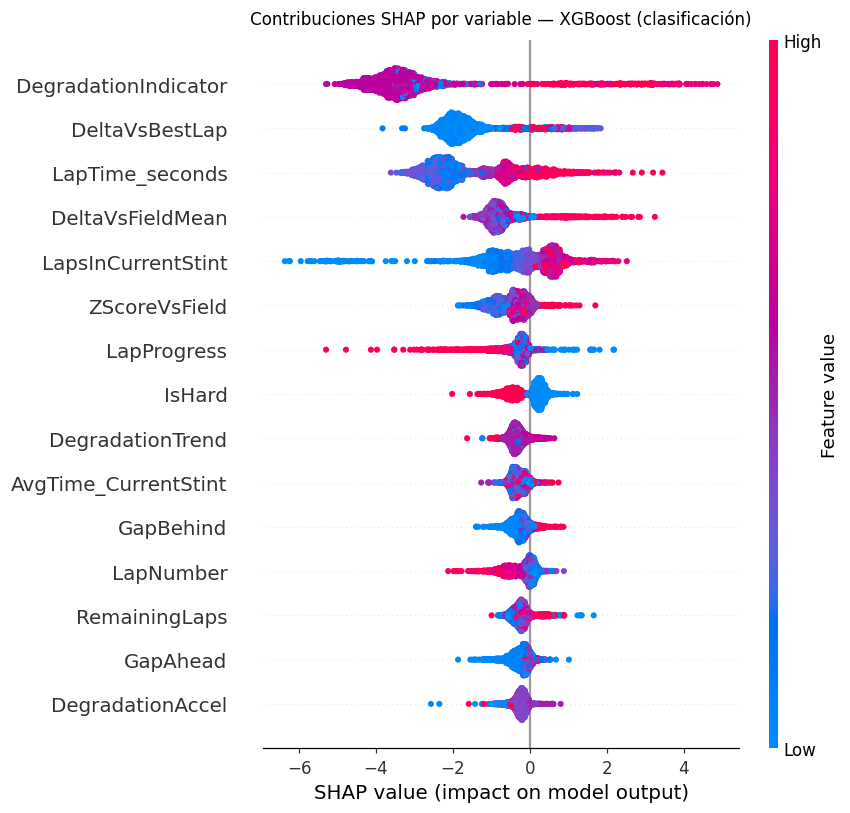

In [9]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_clf, X_shap_clf,
    max_display=TOP_VARIABLES_PLOT,
    show=False,
)
plt.title("Contribuciones SHAP por variable — XGBoost (clasificación)", pad=10)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/fig_shap_global_clf_beeswarm.png", dpi=DPI_FIGURAS, bbox_inches="tight")
plt.show()


### 4.4 *Dependence plots* — caracterización de las variables más influyentes

Para cada una de las variables más influyentes se grafica el valor SHAP frente al valor de la variable, coloreado por la variable con mayor interacción detectada. Esto permite caracterizar relaciones no lineales y umbrales de decisión.

In [10]:
# Identificar las variables más influyentes por SHAP global
importancia_clf = pd.DataFrame({
    "variable": X_shap_clf.columns,
    "importancia_shap": np.abs(shap_values_clf).mean(axis=0),
}).sort_values("importancia_shap", ascending=False)

top_vars_clf = importancia_clf.head(TOP_DEPENDENCE)["variable"].tolist()
print(f"Top {TOP_DEPENDENCE} variables (clasificación): {top_vars_clf}")


Top 3 variables (clasificación): ['DegradationIndicator', 'DeltaVsBestLap', 'LapTime_seconds']


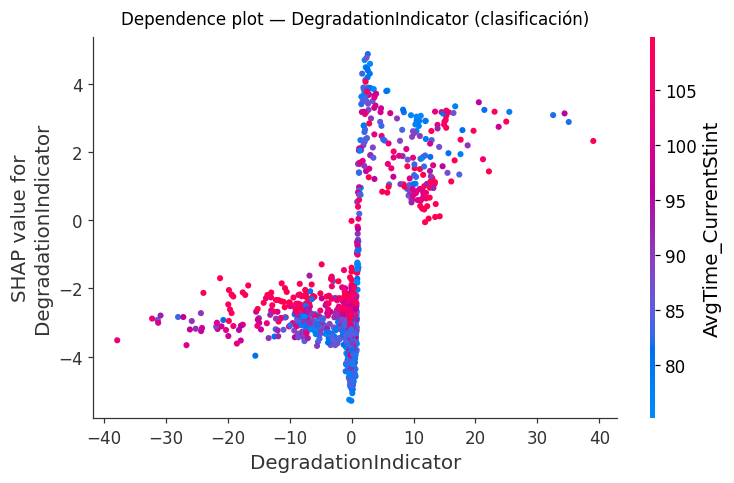

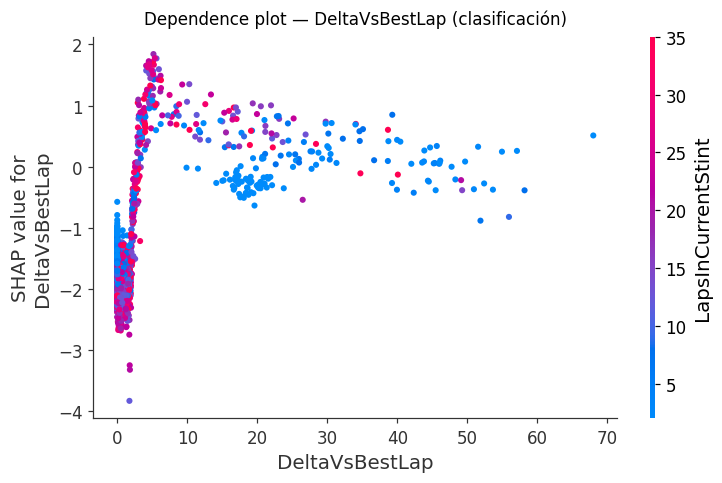

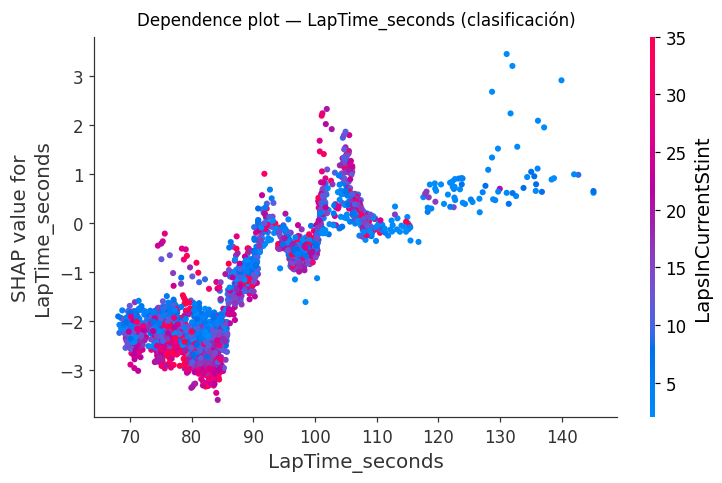

In [11]:
for var in top_vars_clf:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    shap.dependence_plot(
        var, shap_values_clf, X_shap_clf,
        ax=ax, show=False,
    )
    ax.set_title(f"Dependence plot — {var} (clasificación)", pad=8)
    plt.tight_layout()
    nombre_limpio = var.replace("/", "_").replace(" ", "_")
    plt.savefig(f"{OUTPUTS_DIR}/fig_shap_dependence_clf_{nombre_limpio}.png",
                dpi=DPI_FIGURAS, bbox_inches="tight")
    plt.show()


## 5. Análisis SHAP global — modelo de regresión (LightGBM)

En regresión, los valores SHAP están directamente en las unidades de la variable objetivo (vueltas hasta la siguiente parada). Una contribución SHAP de +3 indica que esa variable, en esa observación, ha incrementado la predicción del modelo en 3 vueltas respecto a la predicción media.

In [12]:
# LightGBM no tiene el bug de XGBoost, pero usamos la misma función por uniformidad
explainer_reg = shap.TreeExplainer(modelo_reg)
shap_values_reg = explainer_reg.shap_values(X_shap_reg)

# En regresión, expected_value y shap_values son siempre escalares/arrays simples
if isinstance(shap_values_reg, list):
    shap_values_reg = shap_values_reg[0]
base_value_reg = (explainer_reg.expected_value
                   if np.isscalar(explainer_reg.expected_value)
                   else explainer_reg.expected_value[0])

print(f"shap_values shape: {shap_values_reg.shape}")
print(f"base value (vueltas): {base_value_reg:.2f}")


shap_values shape: (3000, 25)
base value (vueltas): 11.19


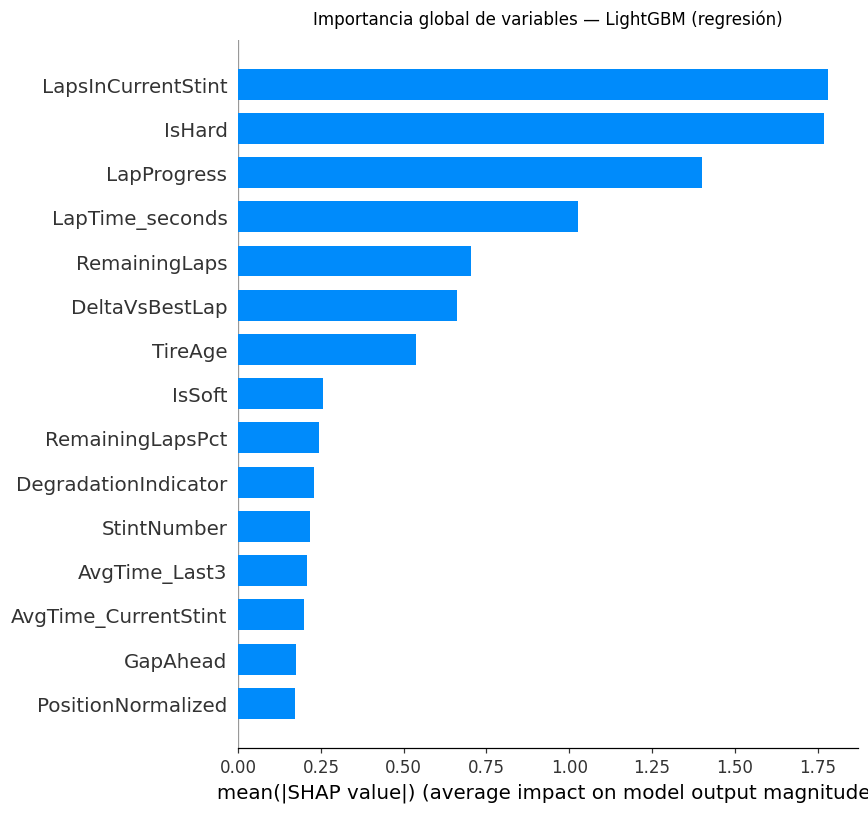

In [13]:
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_reg, X_shap_reg,
    plot_type="bar",
    max_display=TOP_VARIABLES_PLOT,
    show=False,
)
plt.title("Importancia global de variables — LightGBM (regresión)", pad=10)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/fig_shap_global_reg_barras.png", dpi=DPI_FIGURAS, bbox_inches="tight")
plt.show()


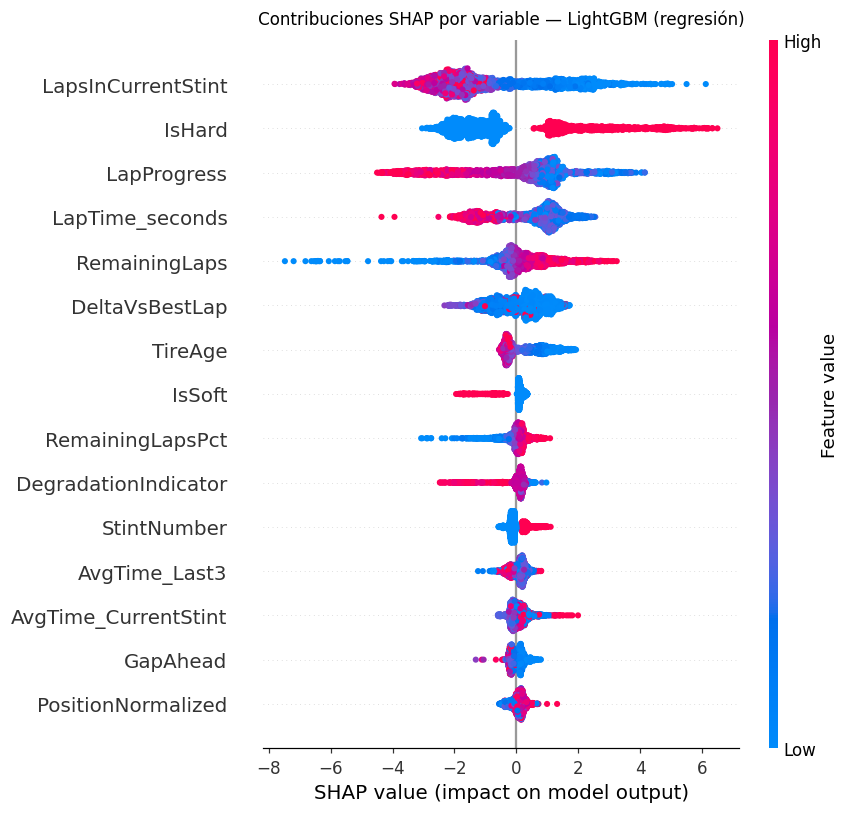

In [14]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_reg, X_shap_reg,
    max_display=TOP_VARIABLES_PLOT,
    show=False,
)
plt.title("Contribuciones SHAP por variable — LightGBM (regresión)", pad=10)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/fig_shap_global_reg_beeswarm.png", dpi=DPI_FIGURAS, bbox_inches="tight")
plt.show()


Top 3 variables (regresión): ['LapsInCurrentStint', 'IsHard', 'LapProgress']


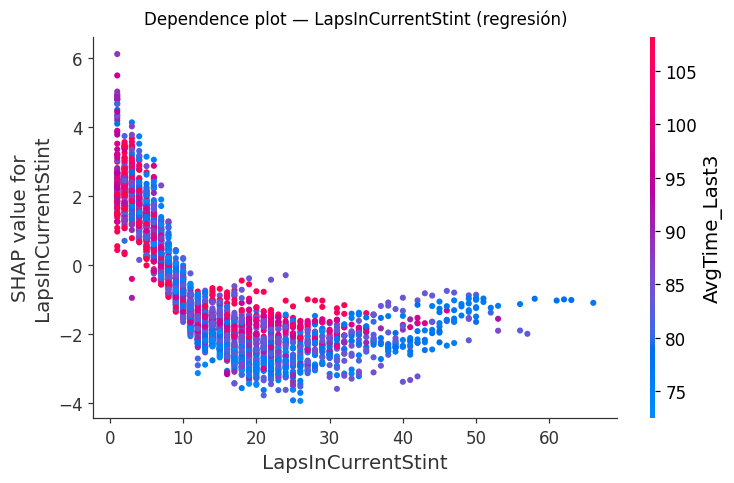

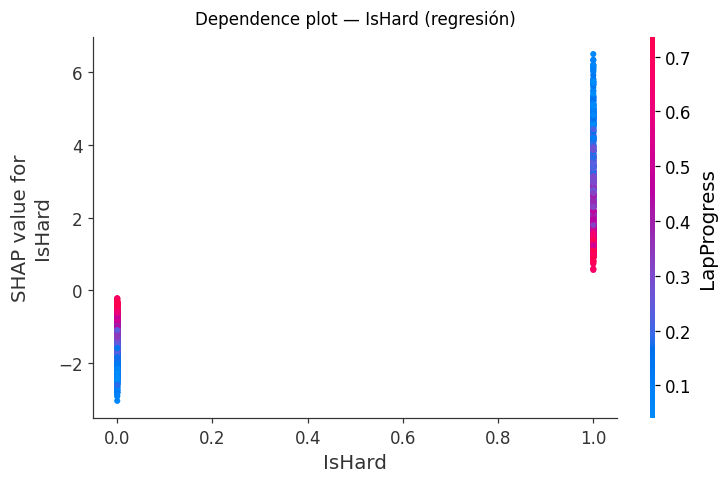

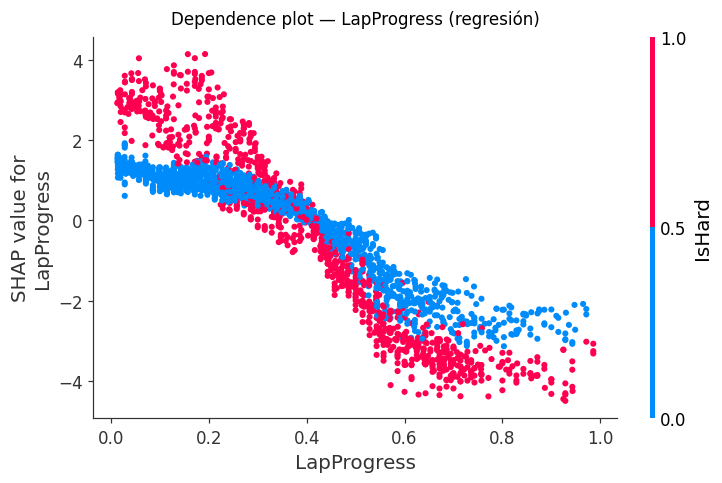

In [15]:
importancia_reg = pd.DataFrame({
    "variable": X_shap_reg.columns,
    "importancia_shap": np.abs(shap_values_reg).mean(axis=0),
}).sort_values("importancia_shap", ascending=False)

top_vars_reg = importancia_reg.head(TOP_DEPENDENCE)["variable"].tolist()
print(f"Top {TOP_DEPENDENCE} variables (regresión): {top_vars_reg}")

for var in top_vars_reg:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    shap.dependence_plot(
        var, shap_values_reg, X_shap_reg,
        ax=ax, show=False,
    )
    ax.set_title(f"Dependence plot — {var} (regresión)", pad=8)
    plt.tight_layout()
    nombre_limpio = var.replace("/", "_").replace(" ", "_")
    plt.savefig(f"{OUTPUTS_DIR}/fig_shap_dependence_reg_{nombre_limpio}.png",
                dpi=DPI_FIGURAS, bbox_inches="tight")
    plt.show()


## 6. Identificación de los casos de error del clasificador

Se identifican los errores cometidos por XGBoost sobre el conjunto de prueba completo y se categorizan según las cuatro tipologías propuestas en la sección 6.6 de la memoria:

1. **Paradas reactivas a eventos imprevisibles** (típicamente coches de seguridad): falsos negativos en vueltas donde la información disponible al modelo no anticipaba la parada.
2. **Paradas anticipadas por undercut táctico**: falsos negativos donde la edad del neumático es moderada pero hay indicios de presión competitiva.
3. **Estrategias atípicas de una y de tres paradas**: errores en pilotos cuya estrategia se aparta del patrón mayoritario del circuito.
4. **Errores cercanos a los extremos de la carrera**: predicciones erróneas en las primeras o últimas vueltas.

### 6.1 Identificación de los errores

In [16]:
# Predicción del clasificador sobre el conjunto de prueba completo
y_pred_test_clf = modelo_clf.predict(X_test_clf)
y_proba_test_clf = modelo_clf.predict_proba(X_test_clf)[:, 1]

errores = pd.DataFrame({
    "y_true": y_test_clf.values if hasattr(y_test_clf, "values") else y_test_clf,
    "y_pred": y_pred_test_clf,
    "proba_parada": y_proba_test_clf,
})
errores["es_error"] = errores["y_true"] != errores["y_pred"]
errores["tipo_error"] = np.where(
    (errores["y_true"] == 1) & (errores["y_pred"] == 0), "FN",
    np.where((errores["y_true"] == 0) & (errores["y_pred"] == 1), "FP", "OK")
)

print(f"Total de muestras de prueba: {len(errores):,}")
print(f"Errores totales: {errores['es_error'].sum():,} ({errores['es_error'].mean()*100:.2f}%)")
print(f"  Falsos negativos: {(errores['tipo_error']=='FN').sum():,}")
print(f"  Falsos positivos: {(errores['tipo_error']=='FP').sum():,}")


Total de muestras de prueba: 18,599
Errores totales: 244 (1.31%)
  Falsos negativos: 129
  Falsos positivos: 115


### 6.2 Unión con metadatos

Los metadatos de cada vuelta (carrera, piloto, número de vuelta, edad de neumático, posición, etc.) ya fueron separados en la sección 3.2 como `meta_test_clf`. Los unimos con los errores para poder categorizar.

In [17]:
# Resetear índices para alinear correctamente
errores = errores.reset_index(drop=True)
meta = meta_test_clf.reset_index(drop=True)
X_test_clf_reset = X_test_clf.reset_index(drop=True)

# Unimos metadatos + features + flag de error.
# Algunas columnas necesarias para la categorización (TyreLife, Position) son features del modelo,
# así que las traemos de X_test_clf, no de meta_test_clf.
casos = pd.concat([meta, X_test_clf_reset, errores], axis=1)
# Eliminar columnas duplicadas si las hubiera (por seguridad)
casos = casos.loc[:, ~casos.columns.duplicated()]

print(f"Tabla de casos: {casos.shape}")
print(f"\nColumnas disponibles (primeras 20):")
print(list(casos.columns)[:20])
print(f"\nPrimeros 3 errores (subset):")
cols_resumen = [c for c in ['Year','RaceRound','Driver','LapNumber','TireAge','Position',
                              'y_true','y_pred','tipo_error'] if c in casos.columns]
print(casos[casos['es_error']][cols_resumen].head(3))


Tabla de casos: (18599, 37)

Columnas disponibles (primeras 20):
['LapsUntilNextStop', 'Season', 'Round', 'Driver', 'EventName', 'EventDate', 'StopLapNumber', 'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator', 'GapAhead', 'GapBehind']

Primeros 3 errores (subset):
    Driver  LapNumber  TireAge  Position  y_true  y_pred tipo_error
222    ALB         40       40       9.0       1       0         FN
365    ANT         71        2      18.0       1       0         FN
398    BEA         29       12      17.0       0       1         FP


### 6.3 Selección de un caso por cada tipología

Las heurísticas siguientes son aproximaciones. Permiten identificar **candidatos** representativos de cada tipología; conviene inspeccionar manualmente los casos seleccionados antes de incorporarlos a la memoria. Si conoces un caso real concreto que ilustra mejor una tipología, puedes sustituirlo directamente por su índice.

**Tipologías y heurísticas**:

| Tipología | Filtro |
|---|---|
| 1. Parada reactiva (coche de seguridad) | FN con `TireAge` baja-media y `lap_number` no extrema |
| 2. Undercut táctico | FN con `TireAge` moderada (15-25) y `Position` competitiva |
| 3. Estrategia atípica | FN con `TireAge` alta y `lap_number` lejos del patrón |
| 4. Extremos de carrera | Error (FN o FP) en `lap_number ≤ 5` o `lap_number ≥ total_laps - 5` |


In [18]:
def buscar_columna(df_, alias):
    """Devuelve el primer alias encontrado en las columnas del df, o None."""
    for nombre in alias:
        if nombre in df_.columns:
            return nombre
    return None

# Detectar nombres reales de las columnas necesarias
col_tyre = buscar_columna(casos, ["TireAge", "tyre_life", "tyrelife", "tyre_age", "stint_lap"])
col_lap = buscar_columna(casos, ["LapNumber", "lap_number", "Lap", "lap"])
col_pos = buscar_columna(casos, ["Position", "position", "GridPosition"])

print(f"Columna usada para edad de neumático: {col_tyre}")
print(f"Columna usada para nº de vuelta: {col_lap}")
print(f"Columna usada para posición: {col_pos}")

def seleccionar_caso(df_casos, condicion, descripcion):
    """Selecciona el caso de la subset con probabilidad más cercana a 0.5 (decisión más ambigua)."""
    subset = df_casos[condicion]
    if len(subset) == 0:
        print(f"  [!] Sin candidatos para: {descripcion}")
        return None
    if "proba_parada" in subset.columns:
        idx = (subset["proba_parada"] - 0.5).abs().idxmin()
    else:
        idx = subset.index[0]
    print(f"  ✓ {descripcion} → idx = {idx} ({len(subset)} candidatos disponibles)")
    return idx

casos_seleccionados = {}

print("Selección de casos por tipología:\n")

# Tipología 1: parada reactiva — FN con neumático joven/medio en vuelta media
if col_tyre and col_lap:
    cond_1 = (
        (casos["tipo_error"] == "FN")
        & (casos[col_tyre].between(5, 18))
        & (casos[col_lap].between(10, 40))
    )
    casos_seleccionados["1_parada_reactiva"] = seleccionar_caso(
        casos, cond_1, "Tipología 1 — parada reactiva (FN, neumático joven-medio, vuelta media)"
    )

# Tipología 2: undercut táctico — FN con neumático moderado y posición competitiva
if col_tyre and col_pos:
    cond_2 = (
        (casos["tipo_error"] == "FN")
        & (casos[col_tyre].between(15, 28))
        & (casos[col_pos].between(2, 10))
    )
    casos_seleccionados["2_undercut_tactico"] = seleccionar_caso(
        casos, cond_2, "Tipología 2 — undercut táctico (FN, neumático medio, top 10)"
    )

# Tipología 3: estrategia atípica — FN con neumático muy desgastado
if col_tyre:
    cond_3 = (
        (casos["tipo_error"] == "FN")
        & (casos[col_tyre] >= 30)
    )
    casos_seleccionados["3_estrategia_atipica"] = seleccionar_caso(
        casos, cond_3, "Tipología 3 — estrategia atípica (FN, neumático muy desgastado)"
    )

# Tipología 4: extremos de carrera — error en primeras o últimas vueltas
if col_lap:
    cond_4 = (
        (casos["tipo_error"].isin(["FN", "FP"]))
        & ((casos[col_lap] <= 5) | (casos[col_lap] >= 60))
    )
    casos_seleccionados["4_extremos_carrera"] = seleccionar_caso(
        casos, cond_4, "Tipología 4 — extremos de carrera (FN/FP en vueltas iniciales o finales)"
    )

casos_seleccionados = {k: v for k, v in casos_seleccionados.items() if v is not None}
print(f"\nCasos finalmente seleccionados: {len(casos_seleccionados)}")


Columna usada para edad de neumático: TireAge
Columna usada para nº de vuelta: LapNumber
Columna usada para posición: Position
Selección de casos por tipología:

  ✓ Tipología 1 — parada reactiva (FN, neumático joven-medio, vuelta media) → idx = 875 (10 candidatos disponibles)
  ✓ Tipología 2 — undercut táctico (FN, neumático medio, top 10) → idx = 7637 (4 candidatos disponibles)
  ✓ Tipología 3 — estrategia atípica (FN, neumático muy desgastado) → idx = 3803 (41 candidatos disponibles)
  ✓ Tipología 4 — extremos de carrera (FN/FP en vueltas iniciales o finales) → idx = 8437 (82 candidatos disponibles)

Casos finalmente seleccionados: 4


## 7. SHAP local — análisis individual de los casos

Para cada caso seleccionado se genera un *waterfall plot*. La interpretación es:

- La línea base es la predicción media del modelo (`E[f(X)]`).
- Cada barra suma o resta a esa base, mostrando cómo cada variable empuja la predicción hacia "parada" (positivo) o "no parada" (negativo) **en este caso concreto**.
- El extremo derecho es la predicción final del modelo para este caso, en escala *log-odds*.

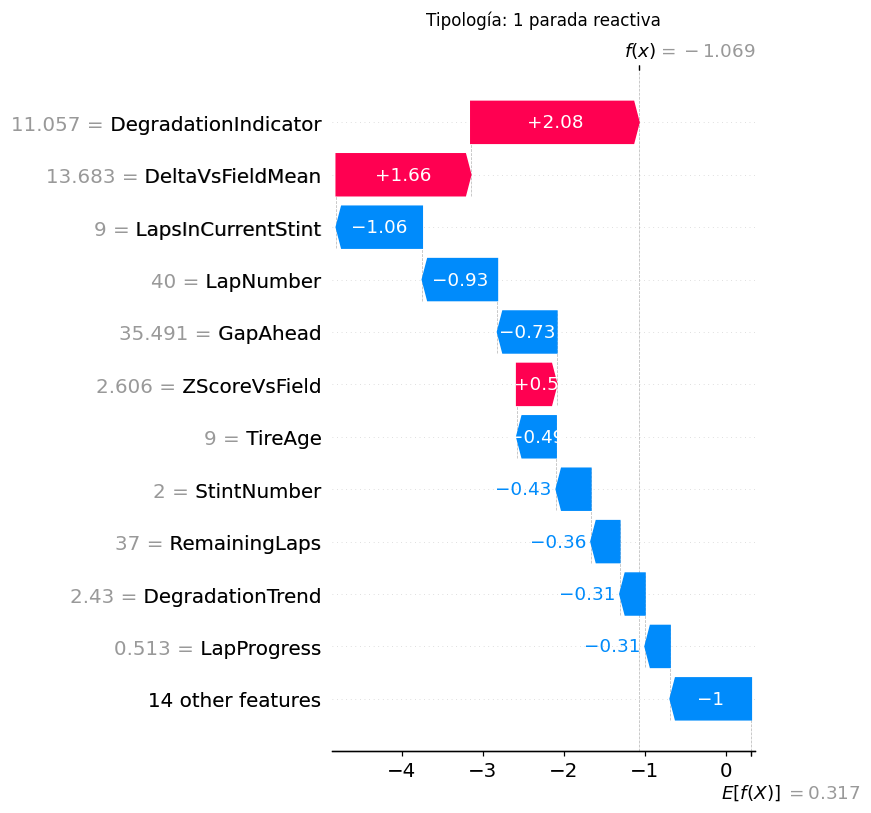

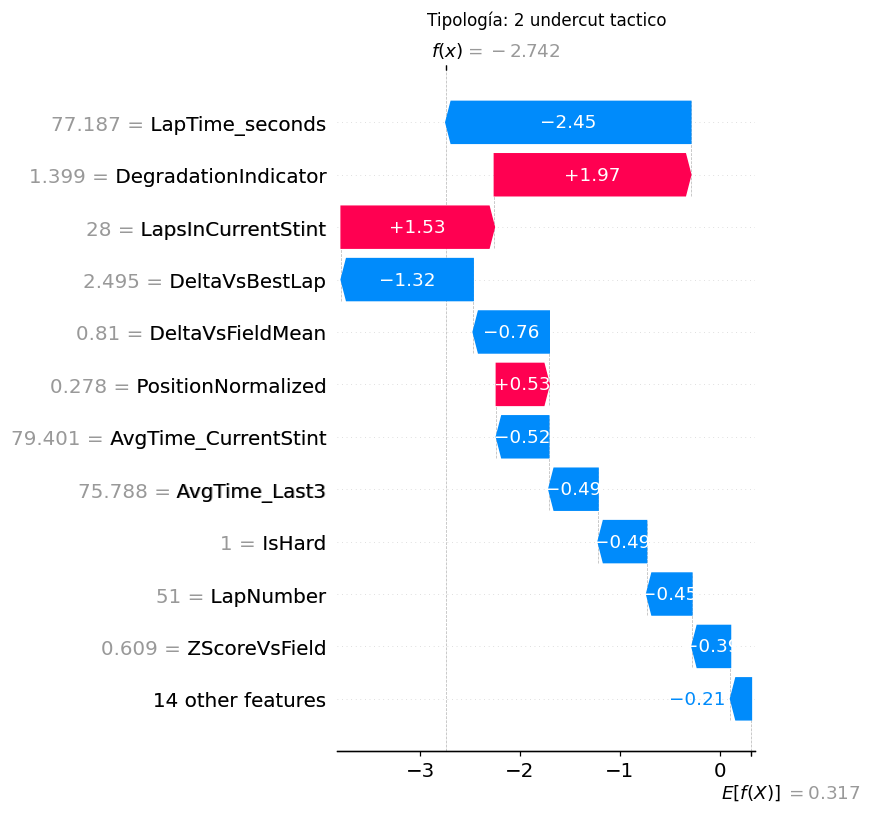

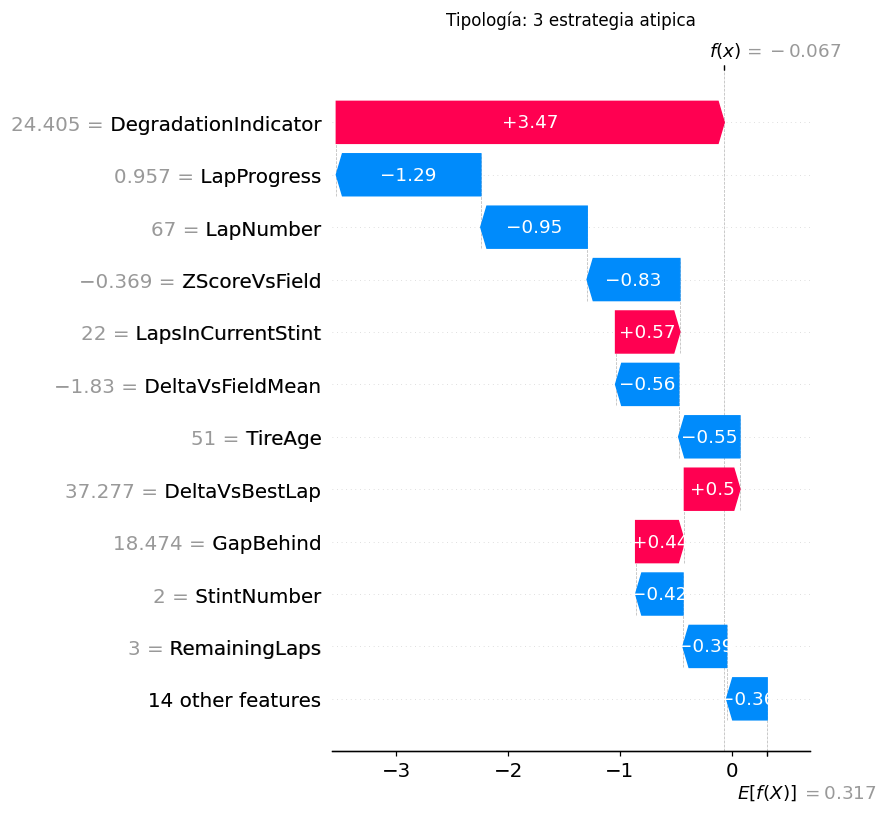

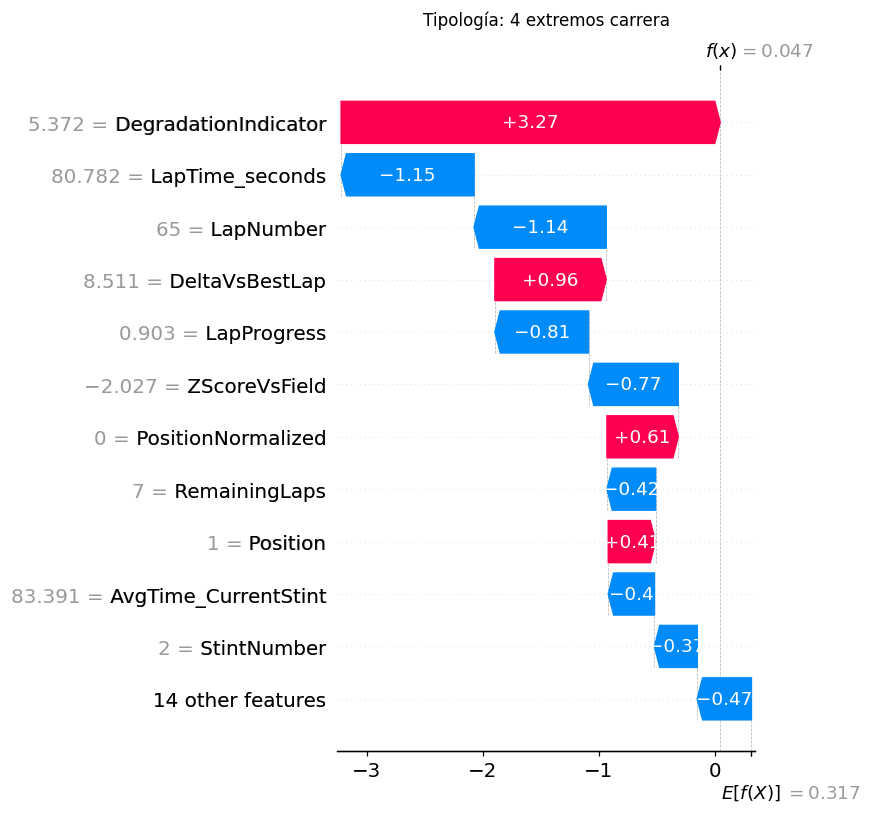


Análisis local completado para 4 casos.


In [19]:
# Calculamos SHAP solo para los casos seleccionados (rápido)
# Nota: 'idx_caso' aquí es la posición en X_test_clf_reset / casos (índice reseteado), no del CSV original

resumen_local = []

for nombre_tipo, idx_caso in casos_seleccionados.items():
    # Recuperar la observación desde X_test_clf_reset (índice posicional 0..N-1)
    X_caso = X_test_clf_reset.iloc[[idx_caso]]

    # SHAP values para este caso individual
    sv_caso = explainer_clf.shap_values(X_caso)
    if isinstance(sv_caso, list):
        sv_caso = sv_caso[1]

    # Construir el objeto Explanation para waterfall
    explanation = shap.Explanation(
        values=sv_caso[0],
        base_values=base_value_clf,
        data=X_caso.iloc[0].values,
        feature_names=list(X_caso.columns),
    )

    # Generar y guardar el waterfall
    fig = plt.figure(figsize=(9, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"Tipología: {nombre_tipo.replace('_', ' ')}", pad=10)
    plt.tight_layout()
    plt.savefig(f"{OUTPUTS_DIR}/fig_shap_local_{nombre_tipo}.png",
                dpi=DPI_FIGURAS, bbox_inches="tight")
    plt.show()

    # Construir fila del resumen con los metadatos disponibles
    fila = {"tipologia": nombre_tipo, "indice_posicional": idx_caso}
    for col in ["Year", "RaceRound", "Driver", "Team", "Circuit",
                 col_lap, col_tyre, col_pos, "tipo_error", "proba_parada"]:
        if col and col in casos.columns:
            try:
                fila[col] = casos.loc[idx_caso, col]
            except Exception:
                pass

    # Top 1 contribución positiva y negativa para este caso
    contribs = pd.Series(sv_caso[0], index=X_caso.columns)
    fila["top_pos_var"] = contribs.idxmax()
    fila["top_pos_shap"] = float(contribs.max())
    fila["top_neg_var"] = contribs.idxmin()
    fila["top_neg_shap"] = float(contribs.min())
    resumen_local.append(fila)

print(f"\nAnálisis local completado para {len(resumen_local)} casos.")


## 8. Resumen consolidado y exportación

### 8.1 Tabla resumen

Esta tabla recoge, para cada caso analizado: la tipología asignada, los metadatos de la vuelta, el tipo de error y las dos variables con mayor contribución SHAP (la que más empuja hacia "parada" y la que más empuja hacia "no parada").

Esta tabla es directamente incorporable a la memoria como evidencia empírica del análisis cualitativo de errores.

In [20]:
df_resumen = pd.DataFrame(resumen_local)
df_resumen.to_csv(f"{OUTPUTS_DIR}/resumen_casos_shap.csv", index=False)
print(f"Resumen exportado a: {OUTPUTS_DIR}/resumen_casos_shap.csv\n")
df_resumen


Resumen exportado a: datasets/prepared/shap_outputs/resumen_casos_shap.csv



,tipologia,indice_posicional,Driver,LapNumber,TireAge,Position,tipo_error,proba_parada,top_pos_var,top_pos_shap,top_neg_var,top_neg_shap
0,1_parada_reactiva,875,LAW,40,9,8.0,FN,0.255530,DegradationIndicator,2.076490,LapsInCurrentStint,-1.062156
1,2_undercut_tactico,7637,ANT,51,28,6.0,FN,0.060524,DegradationIndicator,1.965728,LapTime_seconds,-2.452214
2,3_estrategia_atipica,3803,PIA,67,51,4.0,FN,0.483148,DegradationIndicator,3.469262,LapProgress,-1.292096
3,4_extremos_carrera,8437,PIA,65,42,1.0,FP,0.511856,DegradationIndicator,3.265708,LapTime_seconds,-1.145409


### 8.2 Tabla de importancia SHAP global

Tablas comparativas con la importancia SHAP global de cada variable, tanto para clasificación como para regresión. Útiles para incorporar a la memoria o para discutir en la defensa.

In [21]:
importancia_clf.head(15).to_csv(f"{OUTPUTS_DIR}/importancia_shap_clf.csv", index=False)
importancia_reg.head(15).to_csv(f"{OUTPUTS_DIR}/importancia_shap_reg.csv", index=False)

print("=== Top 15 — Clasificación ===")
print(importancia_clf.head(15).to_string(index=False))
print()
print("=== Top 15 — Regresión ===")
print(importancia_reg.head(15).to_string(index=False))


=== Top 15 — Clasificación ===
            variable  importancia_shap
DegradationIndicator          3.315063
      DeltaVsBestLap          1.709678
     LapTime_seconds          1.602947
    DeltaVsFieldMean          0.830607
  LapsInCurrentStint          0.739771
       ZScoreVsField          0.509921
         LapProgress          0.415227
              IsHard          0.352604
    DegradationTrend          0.346645
AvgTime_CurrentStint          0.298972
           GapBehind          0.291683
           LapNumber          0.290258
       RemainingLaps          0.278595
            GapAhead          0.274300
    DegradationAccel          0.260968

=== Top 15 — Regresión ===
            variable  importancia_shap
  LapsInCurrentStint          1.782501
              IsHard          1.769471
         LapProgress          1.401406
     LapTime_seconds          1.027031
       RemainingLaps          0.702818
      DeltaVsBestLap          0.661872
             TireAge          0.536948
     

### 8.3 Inventario de figuras generadas

Listado de archivos producidos por este notebook. Todos están en alta resolución (300 dpi) y listos para incorporar a la memoria.

In [22]:
archivos_generados = sorted(Path(OUTPUTS_DIR).glob("*.png"))
print(f"Figuras generadas: {len(archivos_generados)}\n")
for archivo in archivos_generados:
    print(f"  - {archivo.name}")

csvs_generados = sorted(Path(OUTPUTS_DIR).glob("*.csv"))
print(f"\nCSVs generados: {len(csvs_generados)}")
for archivo in csvs_generados:
    print(f"  - {archivo.name}")


Figuras generadas: 14

  - fig_shap_dependence_clf_DegradationIndicator.png
  - fig_shap_dependence_clf_DeltaVsBestLap.png
  - fig_shap_dependence_clf_LapTime_seconds.png
  - fig_shap_dependence_reg_IsHard.png
  - fig_shap_dependence_reg_LapProgress.png
  - fig_shap_dependence_reg_LapsInCurrentStint.png
  - fig_shap_global_clf_barras.png
  - fig_shap_global_clf_beeswarm.png
  - fig_shap_global_reg_barras.png
  - fig_shap_global_reg_beeswarm.png
  - fig_shap_local_1_parada_reactiva.png
  - fig_shap_local_2_undercut_tactico.png
  - fig_shap_local_3_estrategia_atipica.png
  - fig_shap_local_4_extremos_carrera.png

CSVs generados: 3
  - importancia_shap_clf.csv
  - importancia_shap_reg.csv
  - resumen_casos_shap.csv


## 9. Guía de integración en la memoria

Tras ejecutar este notebook, los siguientes elementos son candidatos directos a integrarse en la memoria:

### Capítulo 6.4 — Interpretación de la importancia de las variables
- **Sustituir o complementar** la figura actual de feature importance con la figura `fig_shap_global_clf_beeswarm.png`, que combina importancia y direccionalidad.
- Añadir una mención al **dependence plot** de la variable más influyente para caracterizar su efecto no lineal.

### Capítulo 6.6 — Análisis cualitativo de los patrones de error
- **Convertir el análisis hipotético actual en empírico** sustituyendo (o complementando) cada una de las cuatro tipologías por su caso concreto correspondiente.
- Insertar las cuatro figuras `fig_shap_local_*.png` como evidencia visual.
- Añadir una **tabla resumen** con los datos de `resumen_casos_shap.csv`: tipología, carrera, piloto, vuelta, variables más contribuyentes.

### Nueva subsección 6.X — Análisis SHAP de las predicciones
Una opción más ambiciosa es crear una subsección dedicada en el capítulo 6 que recoja toda la interpretabilidad en un único bloque, distinguiendo:
1. Importancia global (figuras `fig_shap_global_*_beeswarm.png` y `fig_shap_global_*_barras.png`).
2. Caracterización de variables clave (figuras `fig_shap_dependence_*`).
3. Análisis local de casos representativos (figuras `fig_shap_local_*`).
4. Discusión sobre la coherencia con la teoría del dominio (undercut, degradación, etc.).

### Plantilla de pie de figura sugerido

> **Figura X**. Diagrama *beeswarm* de los valores SHAP del modelo XGBoost de clasificación sobre el conjunto de prueba. Cada punto representa una observación; el eje horizontal indica la contribución a la predicción (en escala log-odds) y el color, el valor de la variable. Las variables se ordenan por importancia global decreciente. *Fuente: elaboración propia.*

---

**Fin del notebook 9.**
